In [21]:
import requests
import os
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler


In [2]:
def fetch_and_plot_stock_data(stock_symbol):
    """
    Function to fetch historical stock data using Yahoo Finance API and plot the stock prices.

    Parameters:
        stock_symbol (str): The stock symbol to fetch data for (e.g., "AAPL" for Apple Inc.).

    Returns:
        DataFrame: A DataFrame containing the historical stock data.
    """
    try:

        # Fetch stock data
        stock = yf.Ticker(stock_symbol)
        historical_data = stock.history(period="5y")  # Adjust period as needed: "1d", "5d", "1mo", "1y", etc.

        # Display the historical data using pandas
        historical_data.drop(columns=["Dividends", "Stock Splits"], inplace=True)
        print("Historical Data:")
        #drop the first row and rename the first column as date
        historical_data=historical_data.iloc[1:]
        historical_data.reset_index(inplace=True)
        
        print(historical_data.head())


        # Plotting the historical stock prices
        plt.figure(figsize=(12, 6))
        plt.plot(historical_data.index, historical_data["Close"], label="Close Price", color="blue")
        plt.fill_between(historical_data.index, historical_data["Low"], historical_data["High"], color="gray", alpha=0.3, label="High-Low Range")
        plt.title(f"{stock_symbol} Stock Prices (Last Month)", fontsize=16)
        plt.xlabel("Date", fontsize=12)
        plt.ylabel("Price (USD)", fontsize=12)
        plt.legend()
        plt.grid()
        plt.show()
        return historical_data

    except Exception as e:
        print(f"An error occurred: {e}")

Historical Data:
                       Date       Open       High        Low      Close  \
0 2020-01-07 00:00:00-05:00  72.672409  72.929322  72.100418  72.320976   
1 2020-01-08 00:00:00-05:00  72.022858  73.787315  72.022858  73.484352   
2 2020-01-09 00:00:00-05:00  74.465950  75.239113  74.213890  75.045219   
3 2020-01-10 00:00:00-05:00  75.280319  75.782028  74.710747  75.214874   
4 2020-01-13 00:00:00-05:00  75.532386  76.848457  75.413620  76.821793   

      Volume  
0  108872000  
1  132079200  
2  170108400  
3  140644800  
4  121532000  


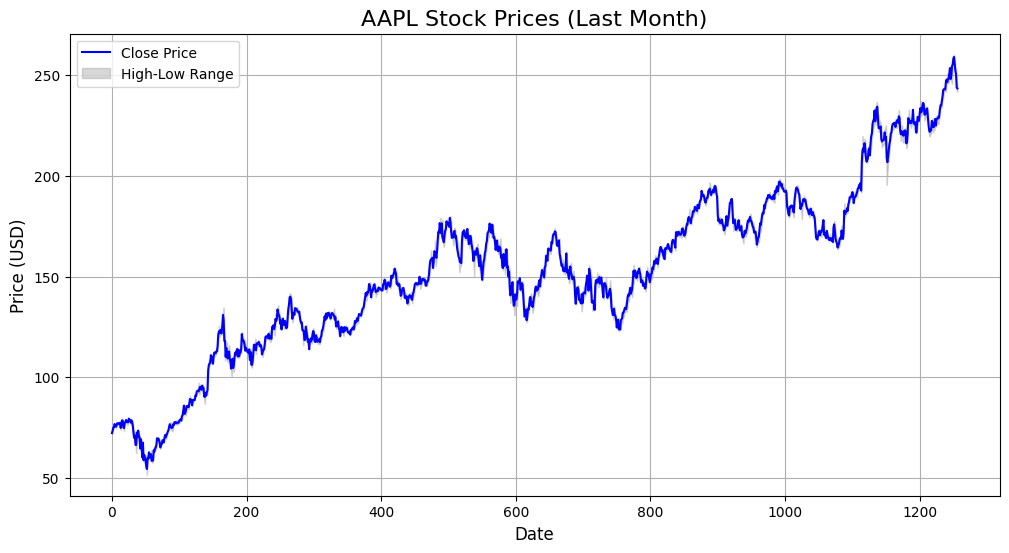

In [3]:
appleStock=fetch_and_plot_stock_data("AAPL")

In [34]:

def plot_stock_trend(df, threshold=5, num_records=100, shift_records=5, figsize=(12, 6)):
    """
    Function to plot stock price trends and annotate trends based on price changes.
    
    Parameters:
        df (DataFrame): The stock price data with 'Date' and 'Close' columns.
        threshold (float): The percentage change threshold for identifying spiky trends (default is 5%).
        num_records (int): The number of most recent records to use for the analysis (default is 100).
        shift_records (int): The number of records to shift for comparing price changes (default is 5).
        figsize (tuple): The size of the plot figure (default is (12, 6)).
    
    Returns:
        DataFrame: A DataFrame with trend information and price changes.
    """
    # Ensure 'Date' is in datetime format and sort by 'Date'
    df['Date'] = pd.to_datetime(df['Date'], utc=True)
    df = df.sort_values(by='Date')


    # Compare with the price `shift_records` records before
    df['Price_Shift_Ago'] = df['Close'].shift(shift_records)
    df['Change'] = df['Close'] - df['Price_Shift_Ago']
    df['Change_Percentage'] = (df['Change'] / df['Price_Shift_Ago']) * 100

    # Determine trends
    def get_trend(row):
        if abs(row['Change_Percentage']) > threshold:  # Spiky trend
            return 'spiky_up' if row['Change'] > 0 else 'spiky_down'
        elif row['Change'] > 0:  # Regular upward trend
            return 'up'
        elif row['Change'] < 0:  # Regular downward trend
            return 'down'
        else:
            return 'neutral'

    df['Trend'] = df.apply(get_trend, axis=1)

    # Plot the Close prices
    plt.figure(figsize=figsize)
    plt.plot(df['Date'], df['Close'], label='Close Price', color='blue', lw=2)

    # Add arrows for trends
    for i in range(shift_records, len(df)):  # Start from `shift_records` record
        trend = df['Trend'].iloc[i]
        if trend == 'up':
            plt.annotate('⬆', xy=(df['Date'].iloc[i], df['Close'].iloc[i]),
                         color='green', fontsize=10, ha='center', va='bottom')
        elif trend == 'down':
            plt.annotate('⬇', xy=(df['Date'].iloc[i], df['Close'].iloc[i]),
                         color='red', fontsize=10, ha='center', va='top')
        elif trend == 'spiky_up':
            plt.annotate('⬆⬆', xy=(df['Date'].iloc[i], df['Close'].iloc[i]),
                         color='darkgreen', fontsize=12, ha='center', va='bottom')
        elif trend == 'spiky_down':
            plt.annotate('⬇⬇', xy=(df['Date'].iloc[i], df['Close'].iloc[i]),
                         color='darkred', fontsize=12, ha='center', va='top')

    # Add labels and title
    plt.title(f'Stock Price Trend with Conditional Spiky Trends - Last {num_records} Records', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Close Price', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    df.dropna(inplace=True)
    df.drop(['Price_Shift_Ago', 'Change_Percentage'], axis=1, inplace=True)
    # scale betweeen -1 and 1
    scaler=StandardScaler()
    df['ScaledChange']=scaler.fit_transform(df['Change'].values.reshape(-1,1))
    print(df.head())
    return df


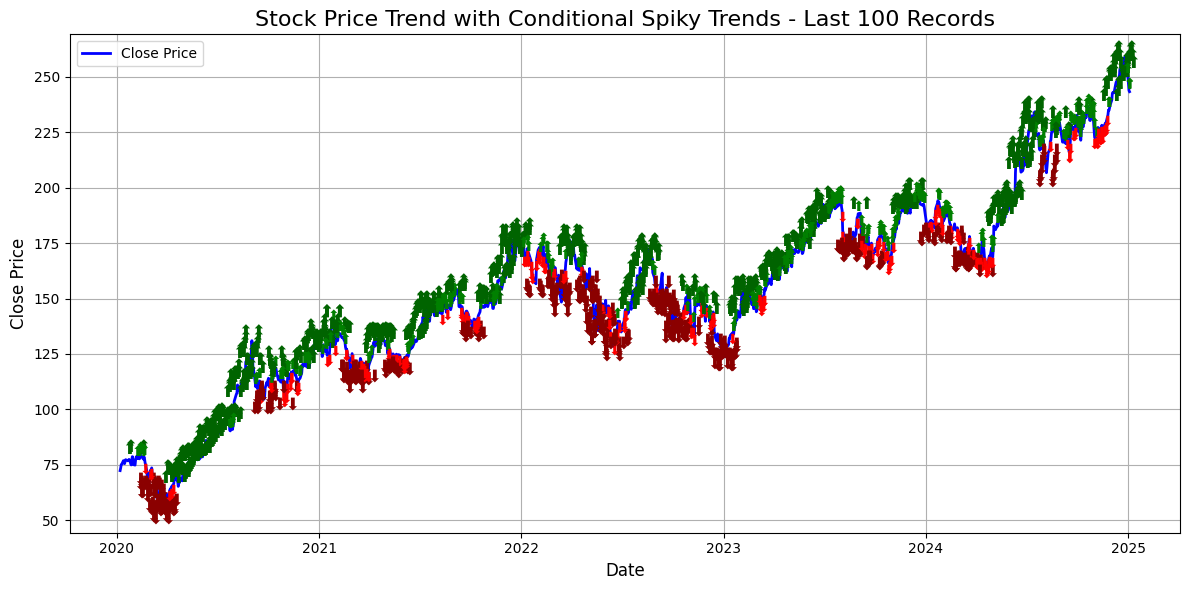

                        Date       Open       High        Low      Close  \
20 2020-02-05 05:00:00+00:00  78.411751  78.712296  77.304123  77.910049   
21 2020-02-06 05:00:00+00:00  78.181495  78.823776  77.621620  78.821350   
22 2020-02-07 05:00:00+00:00  78.318439  78.568673  77.256767  77.749947   
23 2020-02-10 05:00:00+00:00  76.328730  78.119240  76.248561  78.119240   
24 2020-02-11 05:00:00+00:00  78.617285  78.690166  77.429277  77.647926   

       Volume    Change     Trend  ScaledChange  
20  118826800  5.589073  spiky_up      0.245955  
21  105425600  5.336998  spiky_up      0.223648  
22  117684000  2.704727        up     -0.009290  
23  109348800  2.904366        up      0.008376  
24   94323200  0.826134        up     -0.175533  


In [46]:
trendOfApppleStock=plot_stock_trend(appleStock, threshold=5, num_records=100, shift_records=20, figsize=(12, 6))

In [51]:
trendOfApppleStock.reset_index(inplace=True)
trendOfApppleStock.drop(['index'],axis=1,inplace=True)
trendOfApppleStock.drop(['level_0'],axis=1,inplace=True)
trendOfApppleStock.head()

KeyError: "['level_0'] not found in axis"

In [52]:
def calculate_trend_coeff(df, decay_type='sqrt', decay_rate=0.01):
    """
    Function to calculate the trend coefficient with a slower decay, 
    based on changes in the 'Trend' column. Sets coefficient to 2 for "spiky_up" 
    and -2 for "spiky_down", and applies square root or exponential decay for other trends.

    Parameters:
        df (DataFrame): The stock price data with 'Date' and 'Close' columns, and 'Trend' column.
        threshold (float): The percentage change threshold for identifying spiky trends (default is 5%).
        shift_records (int): The number of records to shift for comparing price changes (default is 5).
        decay_type (str): Type of decay to apply ('sqrt' or 'exp'). Default is 'sqrt'.
        decay_rate (float): Rate constant for exponential decay (used if decay_type='exp').

    Returns:
        DataFrame: A DataFrame with the new 'Trend_Coeff' column.
    """
    # Initialize the 'Trend_Coeff' column
    df['Trend_Coeff'] = 0
    trend_coeff = 0
    prev_trend = None
    trend_count = 0

    # Iterate over the Trend column to calculate the Trend_Coeff
    for i in range( len(df)):
        current_trend = df['Trend'].iloc[i]

        # Check for a change in trend
        if (current_trend != prev_trend):
            # Set initial coefficient based on the trend
            if current_trend == 'spiky_up':
                trend_coeff = 2  # Set coefficient to 2 for spiky up
            elif current_trend == 'spiky_down':
                trend_coeff = -2  # Set coefficient to -2 for spiky down
            else:
                trend_coeff = 1 if current_trend == 'up' else -1
            trend_count = 1
        else:
            # Apply slower decay based on the selected decay type
            trend_count += 1
            if decay_type == 'sqrt':
                trend_coeff = trend_coeff / np.sqrt(trend_count)
            elif decay_type == 'exp':
                trend_coeff = trend_coeff * np.exp(-decay_rate * trend_count)

        df['Trend_Coeff'].iloc[i] = trend_coeff
        prev_trend = current_trend

    return df


In [53]:
appleStockWithTrendCoeff=calculate_trend_coeff(trendOfApppleStock, decay_type='exp', decay_rate=0.01)

C:\Users\tarun\AppData\Local\Temp\ipykernel_21524\235833325.py:45: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Trend_Coeff'].iloc[i] = trend_coeff
C:\Users\tarun\AppData\Local\Temp\ipykernel_21524\235833325.py:45: SettingWithCopyWarnin

In [54]:
appleStockWithTrendCoeff.head(20)

,Date,Open,High,Low,Close,Volume,Change,Trend,ScaledChange,Trend_Coeff
0,2020-02-05 05:00:00+00:00,78.411751,78.712296,77.304123,77.910049,118826800,5.589073,spiky_up,0.245955,2.000000
1,2020-02-06 05:00:00+00:00,78.181495,78.823776,77.621620,78.821350,105425600,5.336998,spiky_up,0.223648,1.960397
2,2020-02-07 05:00:00+00:00,78.318439,78.568673,77.256767,77.749947,117684000,2.704727,up,-0.009290,1.000000
3,2020-02-10 05:00:00+00:00,76.328730,78.119240,76.248561,78.119240,109348800,2.904366,up,0.008376,0.980199
4,2020-02-11 05:00:00+00:00,78.617285,78.690166,77.429277,77.647926,94323200,0.826134,up,-0.175533,0.951229
5,2020-02-12 05:00:00+00:00,78.099807,79.496746,78.099807,79.491890,113730400,3.707474,up,0.079446,0.913931
6,2020-02-13 05:00:00+00:00,78.760603,79.253782,78.556529,78.925804,94747600,3.466148,up,0.058090,0.869358
7,2020-02-14 05:00:00+00:00,78.894250,79.195508,78.435086,78.945274,80113600,2.540367,up,-0.023835,0.818731
8,2020-02-18 05:00:00+00:00,76.615391,77.681927,76.433182,77.499718,152531200,0.248932,up,-0.226611,0.763379
9,2020-02-19 05:00:00+00:00,77.742661,78.852925,77.742661,78.622124,93984000,1.894844,up,-0.080959,0.704688


In [60]:
data=appleStockWithTrendCoeff
data['news_score'] = data['Close'].pct_change(periods=20)
# Scale the values to be between -1 and 1 for the news_score column
scaler2=MinMaxScaler(feature_range=(-1, 1))
data['news_score'] = scaler2.fit_transform(data['news_score'].values.reshape(-1, 1))

# Display the first few rows with the new column
data.tail(25)
# data['news_score'].describe()

,Date,Open,High,Low,Close,Volume,Change,Trend,ScaledChange,Trend_Coeff,news_score
1212,2024-11-27 05:00:00+00:00,234.470001,235.690002,233.809998,234.929993,33498400,5.082870,up,0.201159,0.980199,-0.054392
1213,2024-11-29 05:00:00+00:00,234.809998,237.809998,233.970001,237.330002,28481400,11.668274,spiky_up,0.783923,2.000000,0.042156
1214,2024-12-02 05:00:00+00:00,237.270004,240.789993,237.160004,239.589996,48137100,16.924973,spiky_up,1.249105,1.960397,0.121450
1215,2024-12-03 05:00:00+00:00,239.809998,242.759995,238.899994,242.649994,38861000,20.883987,spiky_up,1.599451,1.902459,0.180699
1216,2024-12-04 05:00:00+00:00,242.869995,244.110001,241.250000,243.009995,44383900,19.805573,spiky_up,1.504018,1.827862,0.162956
1217,2024-12-05 05:00:00+00:00,243.990005,244.539993,242.130005,243.039993,40033900,20.564758,spiky_up,1.571201,1.738716,0.175039
1218,2024-12-06 05:00:00+00:00,242.910004,244.630005,242.080002,242.839996,36870600,15.610001,spiky_up,1.132739,1.637462,0.097587
1219,2024-12-09 05:00:00+00:00,241.830002,247.240005,241.750000,246.750000,44649200,19.789993,spiky_up,1.502640,1.526759,0.157942
1220,2024-12-10 05:00:00+00:00,246.889999,248.210007,245.339996,247.770004,36914800,23.540009,spiky_up,1.834490,1.409376,0.215969
1221,2024-12-11 05:00:00+00:00,247.960007,250.800003,246.259995,246.490005,45205800,22.260010,spiky_up,1.721219,1.288073,0.197345
